In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


In [ ]:
data=pd.read_excel("/content/Salary.xlsx")
data.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [ ]:
data.columns
X=data["YearsExperience"]
Y=data["Salary"]
model=LinearRegression()
model.fit(X.values.reshape(-1,1),Y)
y_pred=model.predict(X.values.reshape(-1,1))
r2=r2_score(Y,y_pred)

In [ ]:
data2=pd.read_csv("/content/dataset_edad_precio_seguro.csv")
data2.head()


,Edad,PrecioSeguro
0,18,200
1,22,250
2,25,300
3,30,400
4,35,500


In [ ]:
data2.columns

Index(['Edad', 'PrecioSeguro'], dtype='object')

In [ ]:

X=data2["Edad"]
Y=data2["PrecioSeguro"]
model2=LinearRegression()
model2.fit(X.values.reshape(-1,1),Y)
y_pred2=model2.predict(X.values.reshape(-1,1))
r2d=r2_score(Y,y_pred2)

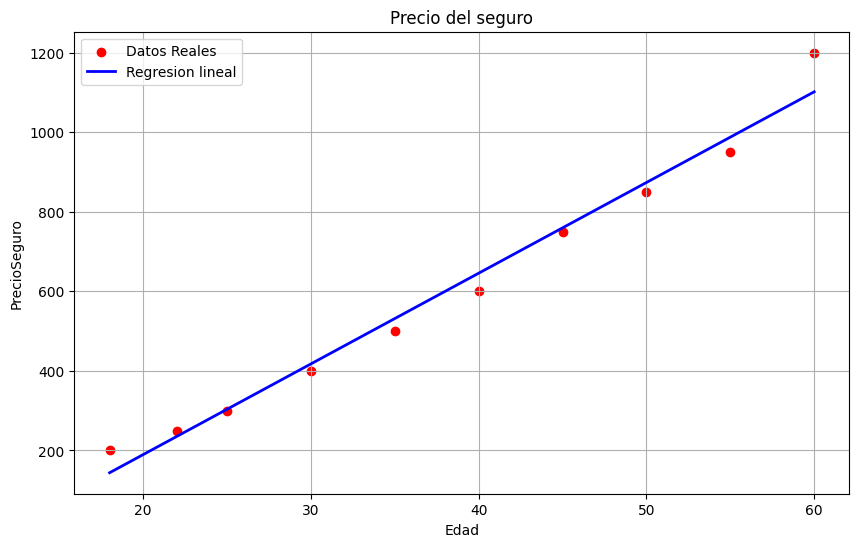

Ecuación de la recta: y= 22.81x+ -266.595289
Coeficiente de Determinación: 0.98


In [ ]:

plt.figure(figsize=[10,6])
plt.scatter(X,Y, color="red",label="Datos Reales")
plt.plot(X,y_pred2,color="Blue",linewidth=2,label="Regresion lineal")
plt.xlabel("Edad")
plt.ylabel("PrecioSeguro")
plt.title("Precio del seguro")
plt.legend()
plt.grid(True)
plt.show()

print(f"Ecuación de la recta: y= {model2.coef_[0]:.2f}x+ {model2.intercept_:2f}")
print(f"Coeficiente de Determinación: {r2d:.2f}")


In [ ]:
data3=pd.read_csv("/content/house_prices_large.csv")
data3.head()

,House_Size,Price
0,143.635030,417.428104
1,287.678577,601.054220
2,232.998485,588.407166
3,199.664621,539.925605
4,89.004660,338.197911


In [ ]:
data3.columns

Index(['House_Size', 'Price'], dtype='object')

In [ ]:

X=data3["House_Size"]
Y=data3["Price"]
model3=LinearRegression()
model3.fit(X.values.reshape(-1,1),Y)
y_pred3=model3.predict(X.values.reshape(-1,1))
r2_pvz=r2_score(Y,y_pred3)

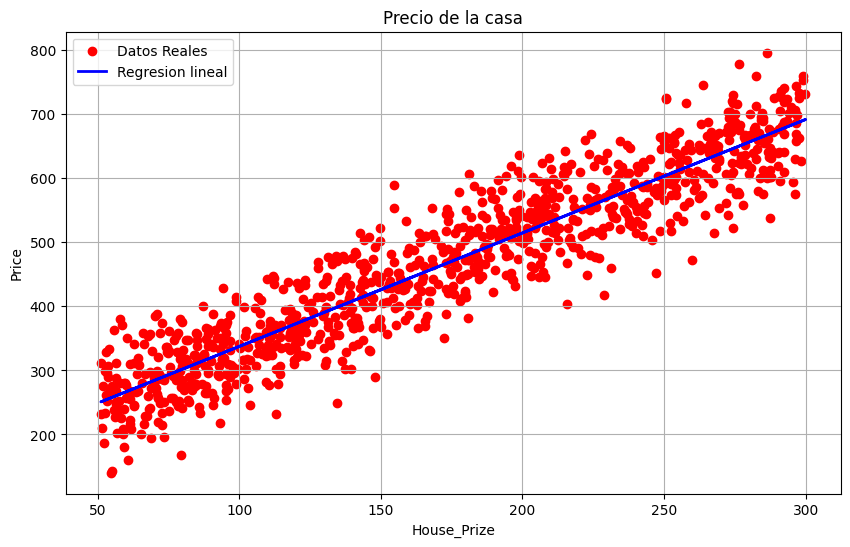

Ecuación de la recta: y= 1.77x+ 160.286865
Coeficiente de Determinación: 0.87


In [ ]:

plt.figure(figsize=[10,6])
plt.scatter(X,Y, color="red",label="Datos Reales")
plt.plot(X,y_pred3,color="Blue",linewidth=2,label="Regresion lineal")
plt.xlabel("House_Prize")
plt.ylabel("Price")
plt.title("Precio de la casa")
plt.legend()
plt.grid(True)
plt.show()

print(f"Ecuación de la recta: y= {model3.coef_[0]:.2f}x+ {model3.intercept_:2f}")
print(f"Coeficiente de Determinación: {r2_pvz:.2f}")


### 1. Desarrollar un EDA y sacar conclusiones
### Exploratory Data Analysis (EDA) – California Housing

**1. Información general**

* Observaciones: **20,640**
* Variables: **10** (9 numéricas, 1 categórica).
* Variable objetivo: `median_house_value` (valor medio de la vivienda).

**2. Valores nulos**

* La única columna con valores faltantes es `total_bedrooms` (207 faltantes).

**3. Estadísticas descriptivas**

* `median_house_value`: media ≈ **206,856 USD**, máx = **500,001** (tope artificial en los datos).
* `median_income`: media ≈ **3.87** (≈ 38,700 USD si se multiplica por 10,000).
* `housing_median_age`: entre **1 y 52 años**, con mediana de 29.
* `total_rooms`: muy disperso, entre 2 y 39,320.
* `households`: promedio ≈ 500 hogares por zona.
* `ocean_proximity`: variable categórica con etiquetas como *NEAR BAY, INLAND, NEAR OCEAN*.

**4. Posibles relaciones**

* Zonas con mayor `median_income` tienden a tener mayor `median_house_value`.
* El número de habitaciones (`total_rooms`) y el número de hogares (`households`) están relacionados, pero no explican bien por sí solos el precio de la vivienda.
* La variable `ocean_proximity` parece relevante: zonas cercanas al océano suelen tener precios más altos.

**5. Conclusiones preliminares**

* El **ingreso medio (`median_income`) es la variable más prometedora** para explicar el valor de la vivienda.
* Existen outliers en `total_rooms`, `population` y `households` que pueden distorsionar modelos lineales.
* `total_bedrooms` tiene algunos valores faltantes, que deben imputarse (mediana o regresión).
* Para un análisis realista, conviene derivar nuevas variables como:

  * `rooms_per_household = total_rooms / households`
  * `bedrooms_per_room = total_bedrooms / total_rooms`
  * `population_per_household = population / households`




In [ ]:
data4=pd.read_csv("/content/housing.csv")
data4.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
data4.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [ ]:

X=data4["total_rooms"]
Y=data4["households"]
model4=LinearRegression()
model4.fit(X.values.reshape(-1,1),Y)
y_pred4=model4.predict(X.values.reshape(-1,1))
r4_pvz=r2_score(Y,y_pred4)

precio de la casa de 4 habitaciones


In [ ]:

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


from google.colab import files
uploaded = files.upload()


df = pd.read_csv(next(iter(uploaded)))


df = df.dropna()


df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)


X = df.drop('median_house_value', axis=1)
y = df['median_house_value']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


sample = X.mean().to_dict()
sample['total_bedrooms'] = 4


sample_df = pd.DataFrame([sample])


predicted_price = model.predict(sample_df)[0]
print(f"💰 Precio estimado para una casa con 4 habitaciones: ${predicted_price:,.2f}")


Saving housing.csv to housing (2).csv
💰 Precio estimado para una casa con 4 habitaciones: $151,578.73


### Regresión lineal de la casa de 4 habitaciones

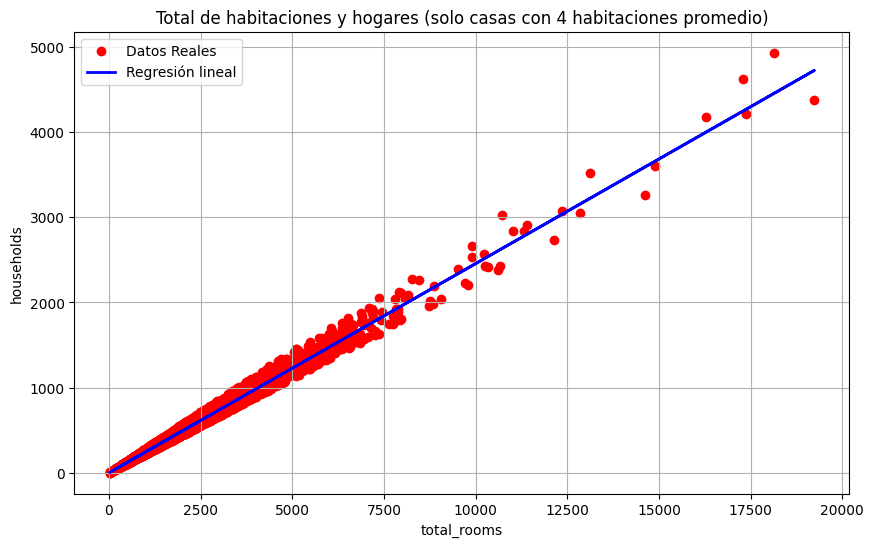

Ecuación de la recta: y = 0.25x + 1.80
Coeficiente de Determinación (R²): 0.99


In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


data4 = pd.read_csv("/content/housing.csv")


data4["rooms_per_household"] = data4["total_rooms"] / data4["households"]


filtro = data4[(data4["rooms_per_household"].round() == 4)]


X = filtro["total_rooms"].values.reshape(-1,1)
Y = filtro["households"].values


model4 = LinearRegression()
model4.fit(X,Y)


y_pred4 = model4.predict(X)
r4_pvz = r2_score(Y,y_pred4)


plt.figure(figsize=[10,6])
plt.scatter(X,Y, color="red",label="Datos Reales")
plt.plot(X,y_pred4,color="blue",linewidth=2,label="Regresión lineal")
plt.xlabel("total_rooms")
plt.ylabel("households")
plt.title("Total de habitaciones y hogares (solo casas con 4 habitaciones promedio)")
plt.legend()
plt.grid(True)
plt.show()


print(f"Ecuación de la recta: y = {model4.coef_[0]:.2f}x + {model4.intercept_:.2f}")
print(f"Coeficiente de Determinación (R²): {r4_pvz:.2f}")

